<a href="https://colab.research.google.com/github/RenanCOliveira93/RenanCOliveira93/blob/main/modalM4_analise_uni_bi_multivariada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## AULA 3 - SWEETVIZ


In [ ]:
!pip install sweetviz

In [2]:
import sweetviz as sv
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython import display

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

In [3]:
metadados = pd.read_excel('metadata.xlsx')

In [4]:
metadados

,Feature,Feature_Type,Description
0,age,numeric,age of a person
1,job,"Categorical,nominal","type of job ('admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')"
2,marital,"categorical,nominal","marital status ('divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)"
3,education,"categorical,nominal","('basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')"
4,default,"categorical,nominal","has credit in default? ('no','yes','unknown')"
5,housing,"categorical,nominal","has housing loan? ('no','yes','unknown')"
6,loan,"categorical,nominal","has personal loan? ('no','yes','unknown')"
7,contact,"categorical,nominal","contact communication type ('cellular','telephone')"
8,month,"categorical,ordinal","last contact month of year ('jan', 'feb', 'mar', …, 'nov', 'dec')"
9,dayofweek,"categorical,ordinal","last contact day of the week ('mon','tue','wed','thu','fri')"


In [5]:
dados = pd.read_csv("new_train.csv", sep=',')

In [8]:
relatorio = sv.analyze(dados,
                       target_feat='y')

                                             |          | [  0%]   00:00 -> (? left)

In [9]:
relatorio.show_html('Analise_sweetviz.html')

Report Analise_sweetviz.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


## AULA 4 - PANDAS


In [12]:
dados.info()
dados.shape
len(dados)
dados.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32950 entries, 0 to 32949
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          32950 non-null  int64 
 1   job          32950 non-null  object
 2   marital      32950 non-null  object
 3   education    32950 non-null  object
 4   default      32950 non-null  object
 5   housing      32950 non-null  object
 6   loan         32950 non-null  object
 7   contact      32950 non-null  object
 8   month        32950 non-null  object
 9   day_of_week  32950 non-null  object
 10  duration     32950 non-null  int64 
 11  campaign     32950 non-null  int64 
 12  pdays        32950 non-null  int64 
 13  previous     32950 non-null  int64 
 14  poutcome     32950 non-null  object
 15  y            32950 non-null  object
dtypes: int64(5), object(11)
memory usage: 4.0+ MB


age              75
job              12
marital           4
education         8
default           3
housing           3
loan              3
contact           2
month            10
day_of_week       5
duration       1467
campaign         40
pdays            27
previous          8
poutcome          3
y                 2
dtype: int64

### Análise Univariada


In [14]:
dados['marital'].tail()

32945     single
32946    married
32947    married
32948    married
32949    married
Name: marital, dtype: object

In [15]:
dados['age'].min()

17

In [16]:
dados['age'].mean()

40.01411229135053

In [17]:
dados['age'].median()

38.0

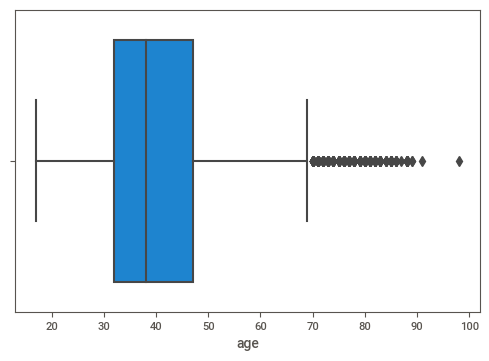

In [18]:
sns.boxplot(x=dados['age'])

In [24]:
display.Image("IQR.png")

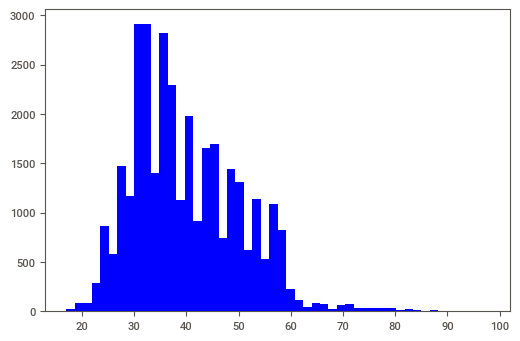

In [26]:
plt.hist(dados['age'], 50, facecolor='b')
plt.show()

In [28]:
dados.describe(include="object")

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,32950,32950,32950,32950,32950,32950,32950,32950,32950,32950,32950
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,8314,19953,9736,26007,17254,27131,20908,11011,6857,28416,29238


In [29]:
dados.isnull().sum()

age            0
job            0
marital        0
education      0
default        0
housing        0
loan           0
contact        0
month          0
day_of_week    0
duration       0
campaign       0
pdays          0
previous       0
poutcome       0
y              0
dtype: int64

In [31]:
dados['poutcome'].value_counts()

nonexistent    28416
failure         3429
success         1105
Name: poutcome, dtype: int64

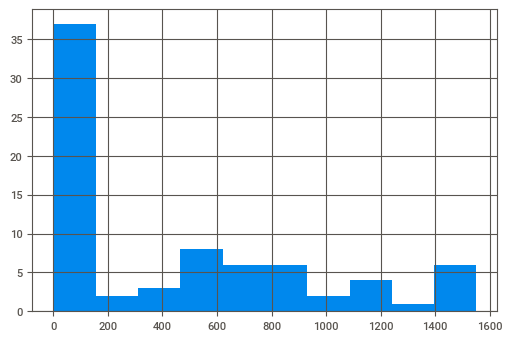

In [32]:
dados['age'].value_counts().hist()

In [34]:
tabela_cross_previous_y = pd.crosstab(index=dados['previous'],
                                      columns=dados['y'],
                                      margins=True)
tabela_cross_previous_y

y,no,yes,All
previous,,,
0,25915,2501,28416
1,2889,784,3673
2,324,282,606
3,74,101,175
4,29,31,60
5,4,10,14
6,2,3,5
7,1,0,1
All,29238,3712,32950


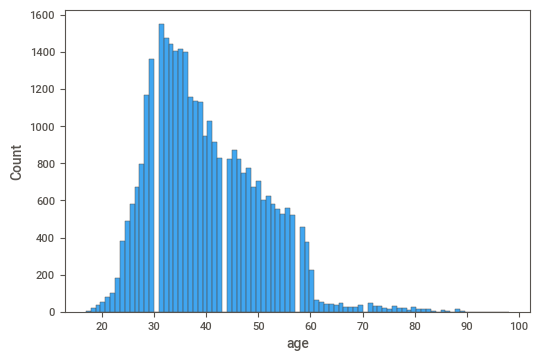

In [35]:
sns.histplot(data=dados, x='age')

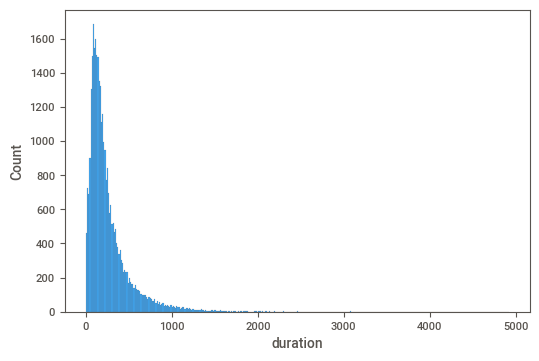

In [38]:
sns.histplot(data=dados, x='duration')

### Análise Bivariada

In [39]:
metadados

,Feature,Feature_Type,Description
0,age,numeric,age of a person
1,job,"Categorical,nominal","type of job ('admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')"
2,marital,"categorical,nominal","marital status ('divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)"
3,education,"categorical,nominal","('basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')"
4,default,"categorical,nominal","has credit in default? ('no','yes','unknown')"
5,housing,"categorical,nominal","has housing loan? ('no','yes','unknown')"
6,loan,"categorical,nominal","has personal loan? ('no','yes','unknown')"
7,contact,"categorical,nominal","contact communication type ('cellular','telephone')"
8,month,"categorical,ordinal","last contact month of year ('jan', 'feb', 'mar', …, 'nov', 'dec')"
9,dayofweek,"categorical,ordinal","last contact day of the week ('mon','tue','wed','thu','fri')"


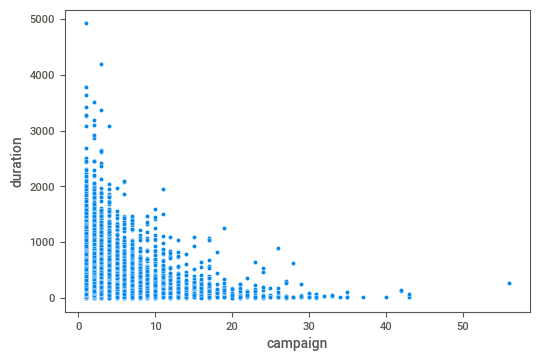

In [41]:
sns.scatterplot(data=dados,
                x='campaign',
                y='duration')

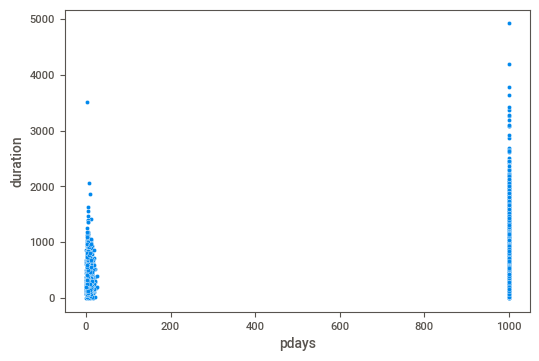

In [42]:
sns.scatterplot(data=dados,
                x='pdays',
                y='duration')

In [44]:
tabela_cross_pdays_duration = pd.crosstab(index=dados['duration'],
                                          columns=dados['pdays'],
                                          margins=True)

tabela_cross_pdays_duration

pdays,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,25,26,27,999,All
duration,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,4
1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,3
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,11,12
5,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,21,22
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,28,28
7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,48,48
8,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,51,52


In [45]:
tabela_cross_default_y = pd.crosstab(index=dados['default'],
                                          columns=dados['y'],
                                          margins=True)

tabela_cross_default_y

y,no,yes,All
default,,,
no,22656,3351,26007
unknown,6579,361,6940
yes,3,0,3
All,29238,3712,32950


In [46]:
dados.corr()

,age,duration,campaign,pdays,previous
age,1.000000,-0.001841,0.003302,-0.032011,0.020670
duration,-0.001841,1.000000,-0.075663,-0.047127,0.022538
campaign,0.003302,-0.075663,1.000000,0.053795,-0.079051
pdays,-0.032011,-0.047127,0.053795,1.000000,-0.589601
previous,0.020670,0.022538,-0.079051,-0.589601,1.000000


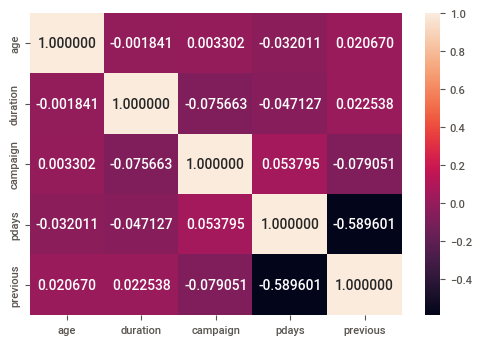

In [47]:
sns.heatmap(dados.corr(), annot=True, fmt='f')

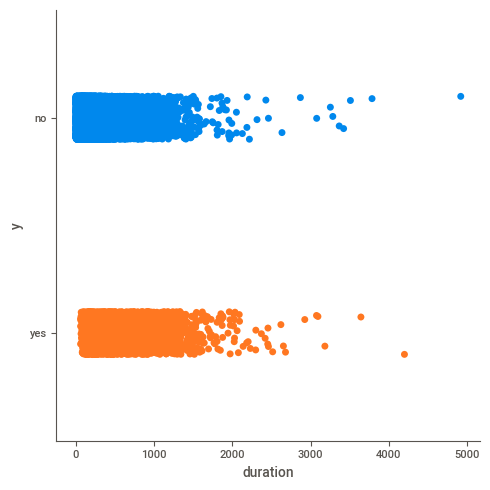

In [48]:
sns.catplot(x='duration',
            y='y',
            data=dados)

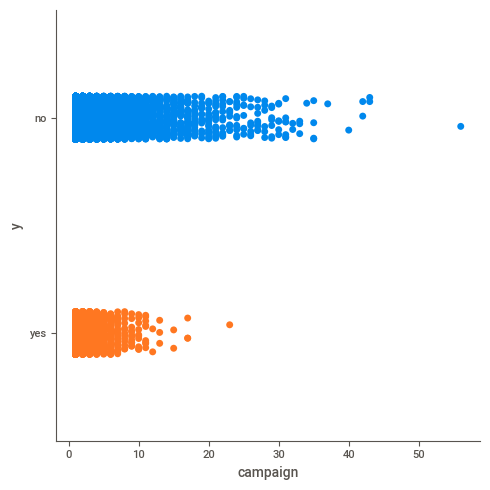

In [49]:
sns.catplot(x='campaign',
            y='y',
            data=dados)

### Análise Multivariada

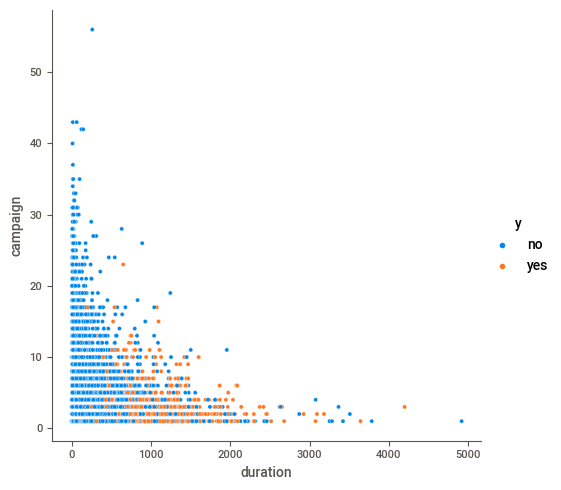

In [54]:
sns.relplot(x='duration',
           y='campaign',
            hue='y',
           data=dados)

In [56]:
dados.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

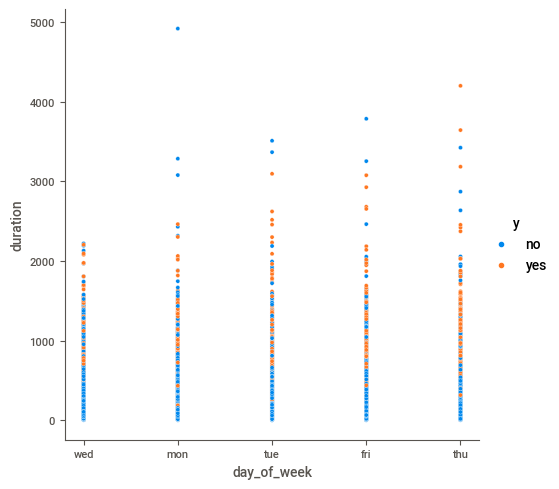

In [61]:
sns.relplot(x='day_of_week',
           y='duration',
            hue='y',
           data=dados)

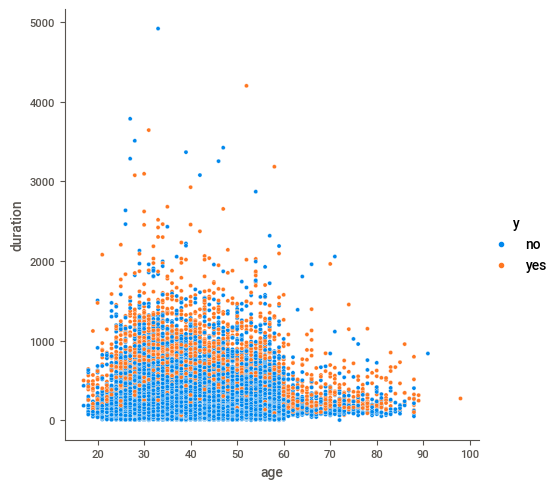

In [59]:
sns.relplot(x='age',
           y='duration',
            hue='y',
           data=dados)

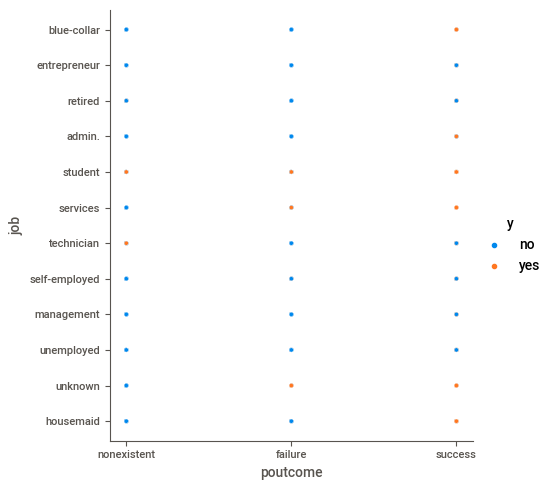

In [67]:
sns.relplot(x='poutcome',
           y='job',
            hue='y',
           data=dados)

### PCA - Análise de Componentes Principais


In [68]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [69]:
metadados

,Feature,Feature_Type,Description
0,age,numeric,age of a person
1,job,"Categorical,nominal","type of job ('admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')"
2,marital,"categorical,nominal","marital status ('divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)"
3,education,"categorical,nominal","('basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')"
4,default,"categorical,nominal","has credit in default? ('no','yes','unknown')"
5,housing,"categorical,nominal","has housing loan? ('no','yes','unknown')"
6,loan,"categorical,nominal","has personal loan? ('no','yes','unknown')"
7,contact,"categorical,nominal","contact communication type ('cellular','telephone')"
8,month,"categorical,ordinal","last contact month of year ('jan', 'feb', 'mar', …, 'nov', 'dec')"
9,dayofweek,"categorical,ordinal","last contact day of the week ('mon','tue','wed','thu','fri')"


In [70]:
dados_pca = dados[['age', 'duration', 'campaign', 'pdays', 'previous']]

dados_pca.head()

,age,duration,campaign,pdays,previous
0,49,227,4,999,0
1,37,202,2,999,1
2,78,1148,1,999,0
3,36,120,2,999,0
4,59,368,2,999,0


In [71]:
pca = PCA(n_components=2,
          random_state=42)

In [72]:
pca

PCA(n_components=2, random_state=42)

In [74]:
dados_pca_ajustado = StandardScaler().fit_transform(dados_pca)
dados_pca_ajustado

array([[ 0.86373877, -0.12019627,  0.52298128,  0.19658384, -0.35012691],
       [-0.28972159, -0.2167318 , -0.20368791,  0.19658384,  1.65381294],
       [ 3.65126795,  3.43617293, -0.56702251,  0.19658384, -0.35012691],
       ...,
       [ 1.34434725, -0.49089273,  0.52298128,  0.19658384, -0.35012691],
       [-1.05869515, -0.3596044 , -0.56702251,  0.19658384, -0.35012691],
       [-0.48196498,  1.10387435,  0.15964669,  0.19658384, -0.35012691]])

In [75]:
resultado_pca = pca.fit_transform(dados_pca_ajustado)
resultado_pca

array([[-0.42517455, -0.50985526],
       [ 1.00537126, -0.14615838],
       [ 0.26558896,  2.27457509],
       ...,
       [-0.43367359, -0.85530087],
       [-0.38430723,  0.36131158],
       [-0.32405825,  0.8294077 ]])

In [77]:
resultado_pca_df = pd.DataFrame(resultado_pca,
                                columns=['componente1', 'componente2'])
resultado_pca_df.head()

,componente1,componente2
0,-0.425175,-0.509855
1,1.005371,-0.146158
2,0.265589,2.274575
3,-0.421084,-0.115342
4,-0.197363,0.194940


In [78]:
pca.explained_variance_ratio_

array([0.32246681, 0.2116934 ])

In [81]:
resultado_pca_df_y = pd.concat([dados['y'], resultado_pca_df], axis=1)
resultado_pca_df_y.head()

,y,componente1,componente2
0,no,-0.425175,-0.509855
1,no,1.005371,-0.146158
2,yes,0.265589,2.274575
3,no,-0.421084,-0.115342
4,no,-0.197363,0.194940


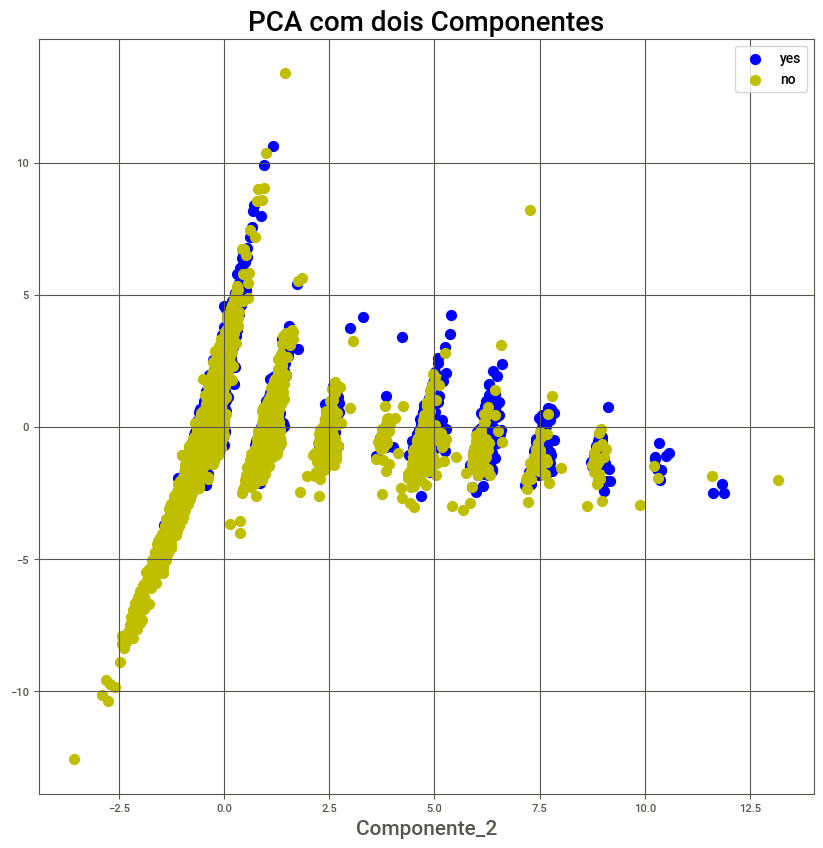

In [90]:
fig = plt.figure(figsize=(10,10))

ax = fig.add_subplot(1,1,1)

ax.set_xlabel('Componente_1', fontsize= 15)
ax.set_xlabel('Componente_2', fontsize= 15)
ax.set_title('PCA com dois Componentes', fontsize= 20)

targets = ['yes', 'no']
colors = ['b', 'y']

for target, cor in zip(targets, colors):
  indices = resultado_pca_df_y['y'] == target
  ax.scatter(resultado_pca_df_y.loc[indices, 'componente1'],
             resultado_pca_df_y.loc[indices, 'componente2'],
             c = cor,
             s= 50)

ax.legend(targets)
ax.grid()